100%|██████████| 26.4M/26.4M [00:02<00:00, 11.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 199kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.75MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 8.27MB/s]


Epoch 1 done.
Epoch 2 done.
Epoch 3 done.
Epsilon: 0.00	Test Accuracy = 8321 / 10000 = 0.8321
Epsilon: 0.01	Test Accuracy = 7841 / 10000 = 0.7841
Epsilon: 0.02	Test Accuracy = 7298 / 10000 = 0.7298
Epsilon: 0.05	Test Accuracy = 5664 / 10000 = 0.5664
Epsilon: 0.10	Test Accuracy = 3178 / 10000 = 0.3178
Epsilon: 0.20	Test Accuracy = 803 / 10000 = 0.0803
Epsilon: 0.40	Test Accuracy = 107 / 10000 = 0.0107
Epsilon: 0.60	Test Accuracy = 129 / 10000 = 0.0129
Epsilon: 0.80	Test Accuracy = 184 / 10000 = 0.0184
Epsilon: 1.00	Test Accuracy = 182 / 10000 = 0.0182


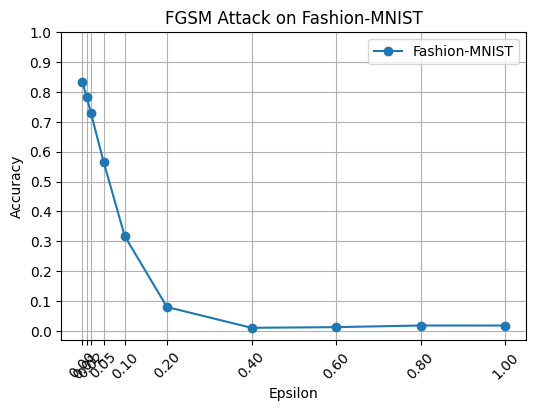

In [19]:
from __future__ import print_function
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import numpy as np

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.conv2_drop = nn.Dropout2d()
        self.fc1 = nn.Linear(320, 50)
        self.fc2 = nn.Linear(50, 10)
    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2_drop(self.conv2(x)), 2))
        x = x.view(-1, 320)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, training=self.training)
        return F.log_softmax(self.fc2(x), dim=1)

use_cuda = False
device = torch.device("cuda" if use_cuda and torch.cuda.is_available() else "cpu")

transform = transforms.Compose([transforms.ToTensor()])
train_loader = torch.utils.data.DataLoader(
    datasets.FashionMNIST('./data', train=True, download=True, transform=transform),
    batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(
    datasets.FashionMNIST('./data', train=False, download=True, transform=transform),
    batch_size=1, shuffle=True)

model = Net().to(device)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
for epoch in range(1, 4):
    model.train()
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch} done.")

def fgsm_attack(image, epsilon, data_grad):
    perturbed = image + epsilon * data_grad.sign()
    return torch.clamp(perturbed, 0, 1)

def test(model, device, test_loader, epsilon):
    model.eval()
    correct = 0
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        data.requires_grad = True
        output = model(data)
        init_pred = output.max(1, keepdim=True)[1]
        if init_pred.item() != target.item():
            continue
        loss = F.nll_loss(output, target)
        model.zero_grad()
        loss.backward()
        perturbed = fgsm_attack(data, epsilon, data.grad)
        output2 = model(perturbed)
        final_pred = output2.max(1, keepdim=True)[1]
        if final_pred.item() == target.item():
            correct += 1
    acc = correct / float(len(test_loader))
    print(f"Epsilon: {epsilon:.2f}\tTest Accuracy = {correct} / {len(test_loader)} = {acc:.4f}")
    return acc

epsilons = [0.0, 0.01, 0.02, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
accuracies = []
for eps in epsilons:
    accuracies.append(test(model, device, test_loader, eps))

import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(epsilons, accuracies, 'o-', label='Fashion-MNIST')
plt.yticks(np.arange(0,1.1,0.1))
plt.xticks(epsilons, rotation=45)
plt.title("FGSM Attack on Fashion-MNIST")
plt.xlabel("Epsilon")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()
